The path volumes are aggregated by using the outputs of `log_all.py`.

In [1]:
import gzip
from multiprocessing import Pool
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm

In [2]:
class VisualizerReader:
    def __init__(self, f, msf_prep_time: int):
        self.f = f
        self.msf_prep_time = msf_prep_time

    def read_header(self):
        f = self.f
        self.width, self.height, self.layer_count = map(int, f.readline().split())
        self.data_qubit_count, self.msf_count = map(int, f.readline().split())
        self.data_qubits = []
        for _ in range(self.data_qubit_count):
            self.data_qubits.append(tuple(map(int, f.readline().split())))
        self.ms_factories = []
        for _ in range(self.msf_count):
            self.ms_factories.append(tuple(map(int, f.readline().split())))
        self.position2qubit_index = {t: i for i, t in enumerate(self.data_qubits)} | {
            t: i for i, t in enumerate(self.ms_factories, start=self.data_qubit_count)
        }
        self.path_count, self.max_timing = map(int, f.readline().split())

    def read_path(self):
        f = self.f
        target_count = int(f.readline())
        targets = list(map(int, f.readline().split()))
        path_length = int(f.readline())
        path = [tuple(map(int, f.readline().split())) for _ in range(path_length)]
        return (targets, path)

    def compute_path_lengths(self):
        self.read_header()
        lengths = []
        for _ in range(self.path_count):
            targets, path = self.read_path()
            lengths.append(len(path))
        assert not self.f.readline()

        metrics = dict()
        metrics["total_code_beat"] = self.max_timing + 1
        metrics["path_lengths"] = lengths

        return metrics

In [3]:
row_arguments = []

result_path = Path("../../out/result")
circuit_paths = result_path.glob("result_SELECT_10_Heisenberg2D_*_5")

for circuit_path in sorted(circuit_paths):
    circuit_name = circuit_path.name
    param_paths = list(circuit_path.glob("*_0"))  # MSF Prep time.
    # param_paths = sum((list(circuit_path.glob(f"*_{t}")) for t in range(0, 11, 2)), [])
    for param_path in sorted(param_paths):
        param_name = param_path.name
        routing_files = []
        routing_files.extend(param_path.glob("*Yes_Kink*"))
        routing_files.extend(param_path.glob("Single_No_Kink*"))
        for routing_file in sorted(routing_files):
            # Note that the following removes ".txt" or ".txt.gz"
            routing_name = routing_file.name.partition(".")[0]
            row_arguments.append((circuit_name, param_name, routing_name, routing_file))

In [4]:
print(len(row_arguments))

84


In [5]:
row_arguments

[('result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5',
  'inner_1_SA_0.001_0',
  'Double_Yes_Kink',
  PosixPath('../../out/result/result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5/inner_1_SA_0.001_0/Double_Yes_Kink.txt.gz')),
 ('result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5',
  'inner_1_SA_0.001_0',
  'Proj_Yes_Kink',
  PosixPath('../../out/result/result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5/inner_1_SA_0.001_0/Proj_Yes_Kink.txt.gz')),
 ('result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5',
  'inner_1_SA_0.001_0',
  'Single_No_Kink',
  PosixPath('../../out/result/result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5/inner_1_SA_0.001_0/Single_No_Kink.txt.gz')),
 ('result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5',
  'inner_1_SA_0.01_0',
  'Double_Yes_Kink',
  PosixPath('../../out/result/result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5/inner_1_SA_0.01_0/Double_Yes_Kink.txt.gz')),
 ('result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5',
  'inner_1_SA_0.01_0',
  'Proj_Yes_Kink',
  PosixPath('../

In [6]:
def compute_row_dict(row_argument):
    circuit_name, param_name, routing_name, routing_file = row_argument
    row = dict()
    row["circuit"] = circuit_name
    (
        row["factory"],
        row["layer_count"],
        row["allocator"],
        row["msf_coeff"],
        row["msf_prep_time"],
    ) = param_name.split("_")
    row["routing_algo"], _, row["routing_option"] = routing_name.partition("_")
    if routing_file.with_suffix(".gz"):
        with gzip.open(routing_file, "rb") as f:
            row |= VisualizerReader(f, int(row["msf_prep_time"])).compute_path_lengths()
    else:
        with open(routing_file, "r") as f:
            row |= VisualizerReader(f, int(row["msf_prep_time"])).compute_path_lengths()

    return row


list_of_row_dict = []
with Pool(16) as p:
    for d in tqdm(
        p.imap_unordered(compute_row_dict, row_arguments), total=len(row_arguments)
    ):
        list_of_row_dict.append(d)

100%|██████████| 84/84 [00:03<00:00, 26.13it/s]


In [7]:
df = pd.DataFrame(list_of_row_dict)
df

,circuit,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,total_code_beat,path_lengths
0,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,inner,1,SA,1,0,Single,No_Kink,329,"[5, 13, 17, 31, 73, 19, 31, 9, 15, 11, 15, 11,..."
1,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,inner,1,SA,0.1,0,Single,No_Kink,328,"[31, 13, 23, 29, 7, 7, 11, 63, 11, 15, 13, 9, ..."
2,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,inner,1,SA,0.001,0,Single,No_Kink,330,"[13, 25, 11, 55, 61, 19, 17, 37, 43, 43, 37, 1..."
3,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,inner,1,SA,1,0,Double,Yes_Kink,300,"[6, 14, 18, 32, 27, 20, 27, 14, 40, 55, 19, 12..."
4,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,inner,1,SA,0.1,0,Double,Yes_Kink,301,"[32, 14, 24, 30, 8, 8, 12, 57, 21, 14, 28, 12,..."
...,...,...,...,...,...,...,...,...,...,...
79,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,2,random,0,0,Single,Yes_Kink,349,"[38, 34, 17, 24, 12, 10, 23, 34, 31, 50, 35, 9..."
80,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,2,random,0,0,Double,Yes_Kink,309,"[38, 35, 16, 24, 12, 10, 23, 49, 43, 71, 40, 6..."
81,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,2,SA,1,0,Proj,Yes_Kink,244,"[6, 10, 6, 17, 12, 6, 9, 6, 8, 6, 8, 13, 13, 1..."
82,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,2,random,0,0,Proj,Yes_Kink,253,"[38, 37, 16, 25, 12, 10, 22, 35, 28, 47, 34, 6..."


In [8]:
def extract_best_sa(df):
    idx = df.groupby(
        [
            "circuit",
            "factory",
            "layer_count",
            "allocator",
            "routing_algo",
            "routing_option",
            "msf_prep_time",
        ]
    )["total_code_beat"].idxmin()
    return df.loc[idx]


df_best = extract_best_sa(df)

In [9]:
df_sa_dim2 = df_best[
    (df_best["layer_count"] == "1") & (df_best["allocator"] == "SA")
].copy()

In [10]:
df_exploded = (
    df_sa_dim2[df_sa_dim2["factory"] == "outer"]
    .explode("path_lengths")
    .reset_index(drop=True)
    .copy()
)
df_exploded["path_lengths"] = pd.to_numeric(
    df_exploded["path_lengths"], errors="coerce"
)
display(df_exploded)

# Each path in Single takes 2 code beats.
df_exploded.loc[df_exploded["routing_algo"] == "Single", "path_lengths"] *= 2
display(df_exploded)

,circuit,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,total_code_beat,path_lengths
0,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,1,SA,0.001,0,Double,Yes_Kink,301,16
1,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,1,SA,0.001,0,Double,Yes_Kink,301,10
2,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,1,SA,0.001,0,Double,Yes_Kink,301,18
3,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,1,SA,0.001,0,Double,Yes_Kink,301,14
4,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,1,SA,0.001,0,Double,Yes_Kink,301,10
...,...,...,...,...,...,...,...,...,...,...
43861,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,1,SA,0.001,0,Single,No_Kink,331,11
43862,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,1,SA,0.001,0,Single,No_Kink,331,21
43863,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,1,SA,0.001,0,Single,No_Kink,331,13
43864,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,1,SA,0.001,0,Single,No_Kink,331,23


,circuit,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,total_code_beat,path_lengths
0,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,1,SA,0.001,0,Double,Yes_Kink,301,16
1,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,1,SA,0.001,0,Double,Yes_Kink,301,10
2,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,1,SA,0.001,0,Double,Yes_Kink,301,18
3,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,1,SA,0.001,0,Double,Yes_Kink,301,14
4,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,1,SA,0.001,0,Double,Yes_Kink,301,10
...,...,...,...,...,...,...,...,...,...,...
43861,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,1,SA,0.001,0,Single,No_Kink,331,22
43862,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,1,SA,0.001,0,Single,No_Kink,331,42
43863,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,1,SA,0.001,0,Single,No_Kink,331,26
43864,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_5,outer,1,SA,0.001,0,Single,No_Kink,331,46


In [11]:
percentiles = [0.25, 0.5, 0.75, 0.95, 0.99]
stats = df_exploded.groupby("routing_algo")["path_lengths"].describe(
    percentiles=percentiles
)
print(stats)

                count       mean        std  min   25%   50%   75%   95%  \
routing_algo                                                               
Double        14622.0  13.873273   9.245026  3.0   8.0  11.0  17.0  30.0   
Proj          14622.0  35.893517  36.955606  3.0  15.0  25.0  44.0  98.0   
Single        14622.0  25.903433  19.824122  6.0  14.0  18.0  34.0  62.0   

                 99%    max  
routing_algo                 
Double         44.79  194.0  
Proj          192.79  428.0  
Single        102.00  394.0  


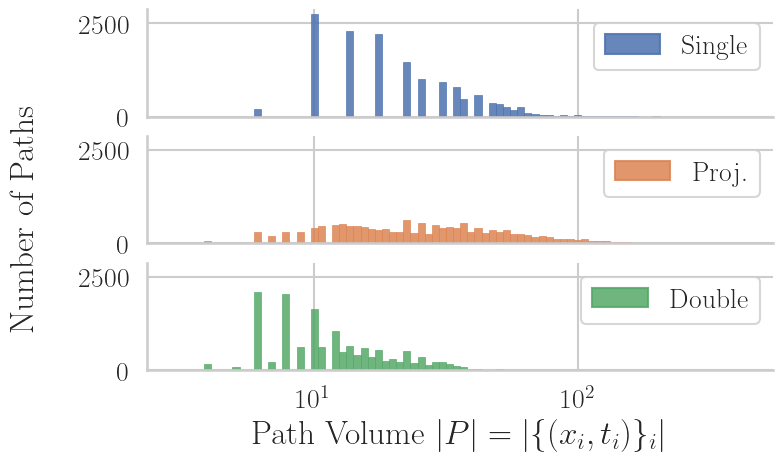

In [ ]:
sns.set_context("talk")
sns.set_style("whitegrid")

plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "axes.unicode_minus": False,
        "text.latex.preamble": r"\usepackage{amsmath}",
    }
)

hue_order = ["Single", "Proj", "Double"]
labels = ["Single", "Proj.", "Double"]

label_map = dict(zip(hue_order, labels))

df_plot = df_exploded.copy()
df_plot["routing_algo_label"] = df_plot["routing_algo"].map(label_map)
df_plot["routing_algo_label"] = pd.Categorical(
    df_plot["routing_algo_label"],
    categories=labels,
    ordered=True,
)

palette = sns.color_palette("deep", n_colors=len(hue_order))
color_map = dict(zip(labels, palette))

g = sns.displot(
    data=df_plot,
    x="path_lengths",
    row="routing_algo_label",
    row_order=labels,
    kind="hist",
    log_scale=True,
    height=1.45,
    aspect=5.4,  # wider than before
    facet_kws={
        "sharex": True,
        "sharey": True,
        "margin_titles": False,
    },
)

g.set_titles("")

g.set_axis_labels("Path Volume", "")
g.set_xlabels("Path Volume $|P| = |\\{(x_i, t_i)\\}_i|$", fontsize=24)
g.figure.supylabel(r"Number of Paths", fontsize=24, x=0.015)

for ax, label in zip(g.axes.flat, labels):
    color = color_map[label]

    for patch in ax.patches:
        patch.set_facecolor(color)
        patch.set_edgecolor(color)
        patch.set_alpha(0.85)

    ax.legend(
        handles=[
            plt.Rectangle(
                (0, 0),
                1,
                1,
                facecolor=color,
                edgecolor=color,
                alpha=0.85,
                label=label,
            )
        ],
        labels=[label],
        loc="upper right",
        frameon=True,
        fontsize=20,
    )

    ax.tick_params(axis="both", which="major", labelsize=20)

# More left margin prevents y-label/tick overlap.
# Wider aspect makes the whole figure more horizontally long.
g.figure.subplots_adjust(
    left=0.19,
    right=0.99,
    top=0.98,
    bottom=0.15,
    hspace=0.18,
)

plt.savefig(
    "../../fig/path_length_histogram_2d_outer.pdf",
    bbox_inches="tight",
)

Single (Outer) 0.95 Percentile: 62.00
Proj (Outer) 0.95 Percentile: 98.00
Double (Outer) 0.95 Percentile: 30.00


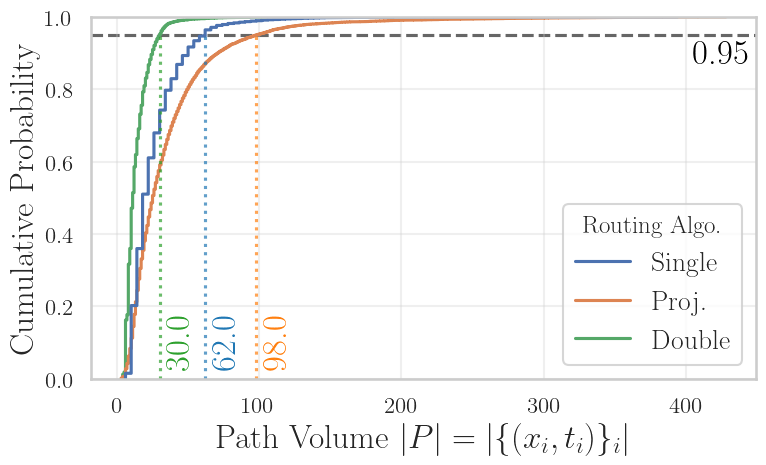

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.set_context("talk")
sns.set_style("whitegrid")

plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "axes.unicode_minus": False,
        "text.latex.preamble": r"\usepackage{amsmath}",
    }
)

percentile = 0.95

# 2. ECDFの描画
sns.ecdfplot(
    data=df_exploded,
    x="path_lengths",
    hue="routing_algo",
    hue_order=hue_order,
    palette="deep",
    ax=ax,
)

# 3. 95%ラインの描画
ax.axhline(percentile, color="k", linestyle="--", alpha=0.6, zorder=-1)

# 4. 各アルゴリズムの95%値を計算してアノテーションを追加
colors = sns.color_palette(n_colors=len(hue_order))
for i, algo in enumerate(hue_order):
    p95_value = df_exploded[df_exploded["routing_algo"] == algo][
        "path_lengths"
    ].quantile(percentile)

    # 垂直線の描画（オプション：交点をわかりやすくするため）
    ax.vlines(p95_value, 0, percentile, color=colors[i], linestyle=":", alpha=0.7)

    ax.annotate(
        f"{p95_value:.1f}",
        xy=(p95_value, 0),
        xytext=(4, 6),
        textcoords="offset points",
        color=colors[i],
        fontweight="heavy",
        fontsize=25,
        va="bottom",
        ha="left",
        rotation=90,
    )
    print(f"{algo} (Outer) {percentile:.2f} Percentile: {p95_value:.2f}")

ax.annotate(
    f"{percentile:.2f}",
    xy=(422, percentile),
    xytext=(3, -3),
    textcoords="offset points",
    color="k",
    fontweight="heavy",
    fontsize=25,
    va="top",
    ha="center",
)

ax.set_xlabel("Path Volume $|P| = |\\{(x_i, t_i)\\}_i|$", fontsize=24)
ax.set_ylabel("Cumulative Probability", fontsize=24)
ax.grid(True, which="both", ls="-", alpha=0.3)
sns.move_legend(
    ax,
    loc="lower right",
    title="Routing Algo.",  # タイトル
    labels=labels,
    frameon=True,
    fontsize=20,
)

plt.tight_layout()
# plt.show()
plt.savefig(
    "../../fig/path_length_ecdf_2d_outer.pdf",
    bbox_inches="tight",
)